In [ ]:
import pandas as pd

In [6]:
data = pd.read_excel('Tableau_data.xlsx')

In [7]:
data

,Year,Product,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,2015,Egg,2.113,2.088,2.133,2.065,1.962,2.570,2.570,2.943,2.966,2.808,2.664,2.751
1,2016,Egg,2.328,2.267,2.081,1.793,1.684,1.491,1.546,1.455,1.471,1.390,1.321,1.383
2,2017,Egg,1.599,1.464,1.404,1.409,1.414,1.332,1.333,1.367,1.422,1.540,1.506,1.815
3,2018,Egg,1.769,1.755,1.831,2.081,1.987,1.628,1.725,1.622,1.651,1.660,1.596,1.595
4,2019,Egg,1.554,1.557,1.544,1.463,1.362,1.203,1.243,1.219,1.383,1.282,1.405,1.535
5,2020,Egg,1.461,1.449,1.525,2.019,1.640,1.554,1.401,1.328,1.353,1.408,1.450,1.481
6,2021,Egg,1.466,1.597,1.625,1.620,1.625,1.642,1.642,1.709,1.835,1.821,1.718,1.788
7,2022,Egg,1.929,2.005,2.046,2.520,2.863,2.707,2.936,3.116,2.902,3.419,3.589,4.250
8,2023,Egg,4.823,4.211,3.446,3.270,2.666,2.219,2.094,2.043,2.065,2.072,2.138,2.507
9,2024,Egg,2.522,2.996,2.992,2.864,2.699,2.715,3.080,3.204,3.821,3.370,3.649,4.146


In [13]:
# Pivot the data from wide to long format
# Convert month columns (Jan-Dec) into rows

# Define the month columns to pivot
month_columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Use pd.melt to pivot the data
pivoted_data = pd.melt(
    data, 
    id_vars=['Year', 'Product'],  # Keep these columns as identifiers
    value_vars=month_columns,     # Convert these columns to rows
    var_name='Month',             # Name for the new column containing month names
    value_name='Price'            # Name for the new column containing the values
)

# Display the pivoted data
print("Pivoted data shape:", pivoted_data.shape)
pivoted_data.head(20)

Pivoted data shape: (528, 4)


,Year,Product,Month,Price
0,2015,Egg,Jan,2.113
1,2016,Egg,Jan,2.328
2,2017,Egg,Jan,1.599
3,2018,Egg,Jan,1.769
4,2019,Egg,Jan,1.554
5,2020,Egg,Jan,1.461
6,2021,Egg,Jan,1.466
7,2022,Egg,Jan,1.929
8,2023,Egg,Jan,4.823
9,2024,Egg,Jan,2.522


In [14]:
# Clean and enhance the pivoted data

# Remove rows with NaN prices (missing data)
pivoted_data_clean = pivoted_data.dropna(subset=['Price']).copy()

# Create a proper date column by combining Year and Month
# First, create a month number mapping
month_mapping = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

# Add month number column
pivoted_data_clean['Month_Num'] = pivoted_data_clean['Month'].map(month_mapping)

# Create a proper datetime column
pivoted_data_clean['Date'] = pd.to_datetime(
    pivoted_data_clean[['Year', 'Month_Num']].assign(day=1).rename(columns={'Month_Num': 'month'})
)

# Reorder columns for better readability
pivoted_data_clean = pivoted_data_clean[['Date', 'Year', 'Month', 'Month_Num', 'Product', 'Price']]

# Sort by Date and Product
pivoted_data_clean = pivoted_data_clean.sort_values(['Date', 'Product']).reset_index(drop=True)

print(f"Clean pivoted data shape: {pivoted_data_clean.shape}")
print(f"Removed {len(pivoted_data) - len(pivoted_data_clean)} rows with missing prices")
pivoted_data_clean.head(15)

Clean pivoted data shape: (503, 6)
Removed 25 rows with missing prices


,Date,Year,Month,Month_Num,Product,Price
0,2015-01-01,2015,Jan,1,Chicken,1.546
1,2015-01-01,2015,Jan,1,Egg,2.113
2,2015-01-01,2015,Jan,1,Milk,3.758
3,2015-01-01,2015,Jan,1,Whole wheat Bread,1.948
4,2015-02-01,2015,Feb,2,Chicken,1.550
5,2015-02-01,2015,Feb,2,Egg,2.088
6,2015-02-01,2015,Feb,2,Milk,3.496
7,2015-02-01,2015,Feb,2,Whole wheat Bread,2.024
8,2015-03-01,2015,Mar,3,Chicken,1.545
9,2015-03-01,2015,Mar,3,Egg,2.133


In [21]:
pivoted_data_clean.to_excel('cleaned_pivoted_data.xlsx', index=False)

In [15]:
# Summary statistics of the pivoted data
print("=== SUMMARY STATISTICS ===")
print(f"\nTotal records: {len(pivoted_data_clean)}")
print(f"Date range: {pivoted_data_clean['Date'].min().strftime('%Y-%m')} to {pivoted_data_clean['Date'].max().strftime('%Y-%m')}")
print(f"\nProducts: {pivoted_data_clean['Product'].unique()}")
print(f"Number of products: {pivoted_data_clean['Product'].nunique()}")

print("\n=== PRICE STATISTICS BY PRODUCT ===")
for product in pivoted_data_clean['Product'].unique():
    product_data = pivoted_data_clean[pivoted_data_clean['Product'] == product]
    print(f"\n{product}:")
    print(f"  Records: {len(product_data)}")
    print(f"  Price range: ${product_data['Price'].min():.3f} - ${product_data['Price'].max():.3f}")
    print(f"  Average price: ${product_data['Price'].mean():.3f}")

=== SUMMARY STATISTICS ===

Total records: 503
Date range: 2015-01 to 2025-06

Products: ['Chicken' 'Egg' 'Milk' 'Whole wheat Bread']
Number of products: 4

=== PRICE STATISTICS BY PRODUCT ===

Chicken:
  Records: 125
  Price range: $1.362 - $2.086
  Average price: $1.644

Egg:
  Records: 126
  Price range: $1.203 - $6.227
  Average price: $2.220

Milk:
  Records: 126
  Price range: $2.839 - $4.218
  Average price: $3.501

Whole wheat Bread:
  Records: 126
  Price range: $1.896 - $2.833
  Average price: $2.185


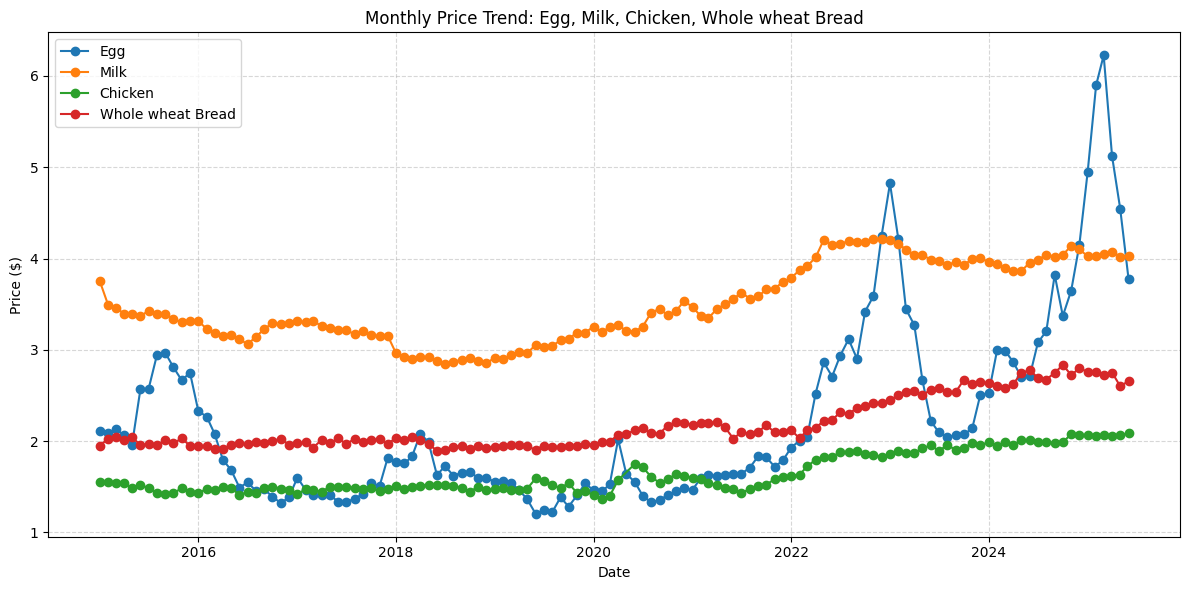

In [16]:
import matplotlib.pyplot as plt

# Filter for the 4 products
products_to_plot = ['Egg', 'Milk', 'Chicken', 'Whole wheat Bread']
plot_data = pivoted_data_clean[pivoted_data_clean['Product'].isin(products_to_plot)]

plt.figure(figsize=(12, 6))
for product in products_to_plot:
    prod_data = plot_data[plot_data['Product'] == product]
    plt.plot(prod_data['Date'], prod_data['Price'], marker='o', label=product)

plt.title('Monthly Price Trend: Egg, Milk, Chicken, Whole wheat Bread')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

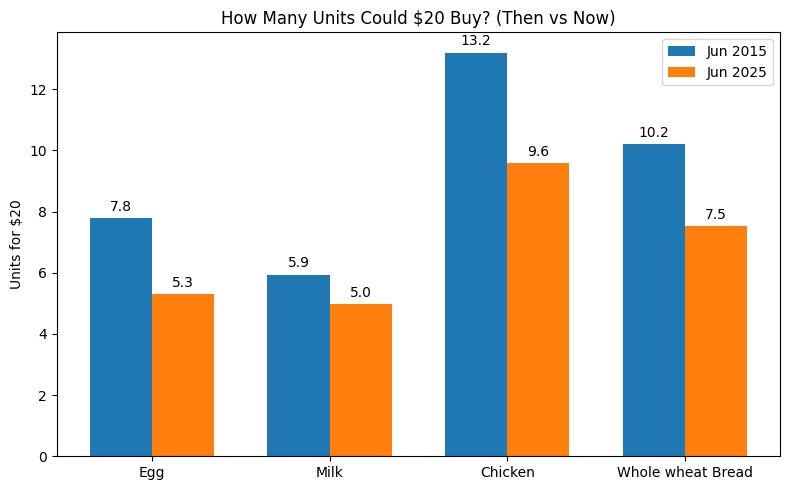

In [20]:
import numpy as np

# Calculate how many units $20 could buy for each product in Jan 2015 and the latest available month

products = ['Egg', 'Milk', 'Chicken', 'Whole wheat Bread']
amount = 20

# Get Jan 2015 prices
jan_2015 = pivoted_data_clean[(pivoted_data_clean['Year'] == 2015) & (pivoted_data_clean['Month'] == 'Jun')]
latest_date = pivoted_data_clean['Date'].max()
latest = pivoted_data_clean[pivoted_data_clean['Date'] == latest_date]

units_2015 = []
units_now = []

for prod in products:
    price_2015 = jan_2015[jan_2015['Product'] == prod]['Price'].values[0]
    price_now = latest[latest['Product'] == prod]['Price'].values[0]
    units_2015.append(amount / price_2015)
    units_now.append(amount / price_now)

# Plotting
import matplotlib.pyplot as plt

x = np.arange(len(products))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, units_2015, width, label='Jun 2015')
rects2 = ax.bar(x + width/2, units_now, width, label=latest_date.strftime('%b %Y'))

ax.set_ylabel('Units for $20')
ax.set_title('How Many Units Could $20 Buy? (Then vs Now)')
ax.set_xticks(x)
ax.set_xticklabels(products)
ax.legend()
ax.bar_label(rects1, fmt='%.1f', padding=3)
ax.bar_label(rects2, fmt='%.1f', padding=3)
plt.tight_layout()
plt.show()

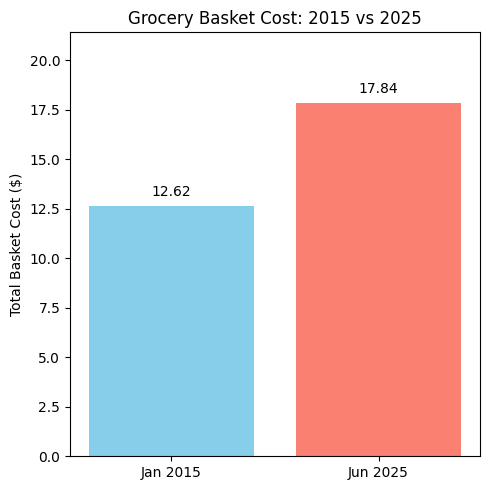

Basket: {'Egg': 2, 'Milk': 1, 'Chicken': 3}
Total cost in Jan 2015: $12.62
Total cost in Jun 2025: $17.84


In [19]:
# Define your grocery basket: keys are product names, values are quantities
basket = {
    'Egg': 2,         # 2 dozen eggs
    'Milk': 1,        # 1 gallon milk
    'Chicken': 3      # 3 lbs chicken
}

# Get Jan 2015 and Jun 2025 prices for each product in the basket
basket_2015 = {}
basket_2025 = {}

for prod, qty in basket.items():
    price_2015 = jan_2015[jan_2015['Product'] == prod]['Price'].values[0]
    price_2025 = latest[latest['Product'] == prod]['Price'].values[0]
    basket_2015[prod] = price_2015 * qty
    basket_2025[prod] = price_2025 * qty

total_2015 = sum(basket_2015.values())
total_2025 = sum(basket_2025.values())

# Plot the basket cost comparison
labels = ['Jan 2015', latest_date.strftime('%b %Y')]
totals = [total_2015, total_2025]

plt.figure(figsize=(5, 5))
bars = plt.bar(labels, totals, color=['skyblue', 'salmon'])
plt.ylabel('Total Basket Cost ($)')
plt.title('Grocery Basket Cost: 2015 vs 2025')
plt.bar_label(bars, fmt='%.2f', padding=5)
plt.ylim(0, max(totals) * 1.2)
plt.tight_layout()
plt.show()

# Show the basket and totals
print("Basket:", basket)
print(f"Total cost in Jan 2015: ${total_2015:.2f}")
print(f"Total cost in {latest_date.strftime('%b %Y')}: ${total_2025:.2f}")